# Импорты библиотек

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import joblib
import gdown
import json
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.feature_selection import SelectKBest, f_classif
import xgboost as xgb

# Загрузка датасета

In [ ]:
file_id='1G1fmKedJ5S64165Zs8IeU_uOZvj-OLhn'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'dataset.csv'
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1G1fmKedJ5S64165Zs8IeU_uOZvj-OLhn
To: /content/dataset.csv
100%|██████████| 3.61M/3.61M [00:00<00:00, 28.7MB/s]


'dataset.csv'

Прверяем, что датасет загрузился

In [ ]:
import pandas as pd

df = pd.read_csv(output)
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


# Первичный анализ данных

Размер датасета

In [ ]:
print(f'Размер датасета: {df.shape}, где \n{df.shape[0]} - количество строк \n{df.shape[1]} - количество столбцов')

Размер датасета: (45000, 14), где 
45000 - количество строк 
14 - количество столбцов


Типы данных

In [ ]:
print(f'Типы данных:\n{df.dtypes}')

Типы данных:
person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object


Баланс классов

In [ ]:
print(f'Баланс классов:\n{df['loan_status'].value_counts()}')

Баланс классов:
loan_status
0    35000
1    10000
Name: count, dtype: int64


Доля одобренных ипотек

In [ ]:
print(f'Доля одобренных ипотек: {df['loan_status'].mean():.2%}')

Доля одобренных ипотек: 22.22%


Количество пропусков

In [ ]:
print(f'Количество пропусков:\n{df.isnull().sum()}')

Количество пропусков:
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


# Очистка данных

In [ ]:
df_clean = df.copy()

Обработка пропусков

In [ ]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

categorical_cols = df_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f'Пропуски обработаны. Осталось: {df_clean.isnull().sum().sum()} пропусков')


Пропуски обработаны. Осталось: 0 пропусков


Обработка выбросов

In [ ]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

initial_len = len(df_clean)
outlier_cols = ['person_age', 'person_income', 'loan_amnt', 'credit_score']
for col in outlier_cols:
    df_clean = remove_outliers(df_clean, col)

print(f'Выбросы обработаны. Удалено: {initial_len - len(df_clean)} ({100*(initial_len - len(df_clean))/initial_len:.1f}%) выбросов')

Выбросы обработаны. Удалено: 6423 (14.3%) выбросов


# Визуализация данных

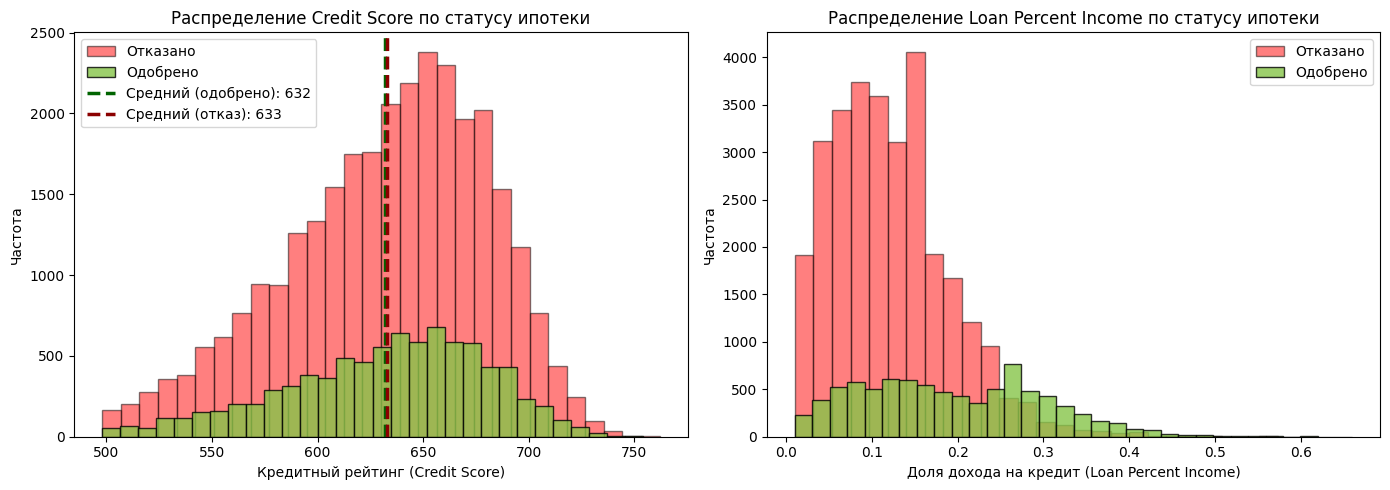


График сохранён: eda_analysis.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Credit Score vs Loan Status
good_credit = df_clean[df_clean['loan_status'] == 1]['credit_score']
bad_credit = df_clean[df_clean['loan_status'] == 0]['credit_score']

axes[0].hist(bad_credit, bins=30, alpha=0.5, label='Отказано', color='red', edgecolor='black', zorder=1)
axes[0].hist(good_credit, bins=30, alpha=0.8, label='Одобрено', color='#86c548', edgecolor='black', zorder=2)

axes[0].set_xlabel('Кредитный рейтинг (Credit Score)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение Credit Score по статусу ипотеки')

axes[0].axvline(good_credit.mean(), color='darkgreen', linestyle='dashed', linewidth=2.5,
                label=f'Средний (одобрено): {good_credit.mean():.0f}')
axes[0].axvline(bad_credit.mean(), color='darkred', linestyle='dashed', linewidth=2.5,
                label=f'Средний (отказ): {bad_credit.mean():.0f}')

axes[0].legend()

# График 2: Loan Percent Income vs Loan Status
good_income = df_clean[df_clean['loan_status'] == 1]['loan_percent_income']
bad_income = df_clean[df_clean['loan_status'] == 0]['loan_percent_income']

axes[1].hist(bad_income, bins=30, alpha=0.5, label='Отказано', color='red', edgecolor='black', zorder=1)
axes[1].hist(good_income, bins=30, alpha=0.8, label='Одобрено', color='#86c548', edgecolor='black', zorder=2)

axes[1].set_xlabel('Доля дохода на кредит (Loan Percent Income)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение Loan Percent Income по статусу ипотеки')

axes[1].legend()

plt.tight_layout()
plt.show()
plt.savefig('eda_analysis.png', dpi=150)
plt.close()
print('\nГрафик сохранён: eda_analysis.png')

# Подготовка признаков (кодирование и масштабирование)

In [ ]:
X = df_clean.drop('loan_status', axis=1)
y = df_clean['loan_status']

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'\nЧисловые признаки ({len(numeric_features)}): {numeric_features}')
print(f'Категориальные признаки ({len(categorical_features)}): {categorical_features}')

numeric_transformer = Pipeline([('scaler', StandardScaler())])
categorical_transformer = Pipeline([('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_processed = preprocessor.fit_transform(X)
feature_names = (numeric_features +
                 list(preprocessor.named_transformers_['cat']
                      .named_steps['onehot']
                      .get_feature_names_out(categorical_features)))

print(f'\nПосле One-Hot кодирования: {X_processed.shape[1]} признаков')


Числовые признаки (8): ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
Категориальные признаки (5): ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']

После One-Hot кодирования: 22 признаков


# Отбор признаков

In [ ]:
selector = SelectKBest(score_func=f_classif, k=15)
X_selected = selector.fit_transform(X_processed, y)

selected_mask = selector.get_support()
selected_features = [feature_names[i] for i in range(len(feature_names)) if selected_mask[i]]

print(f'Отобрано {len(selected_features)} лучших признаков из {len(feature_names)}')
print(f'Топ-5 лучших признаков: {selected_features[:5]}')

Отобрано 15 лучших признаков из 22
Топ-5 лучших признаков: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate']


# Обучение моделей

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

Модель XGBoost

In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_pred)
print(f'XGBoost ROC-AUC: {xgb_auc:.4f}')

# Кросс-валидация
xgb_cv = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='roc_auc')

print(f'5-fold кросс-валидация:')
print(f'  XGBoost: {xgb_cv.mean():.4f} (+/- {xgb_cv.std():.4f})')

XGBoost ROC-AUC: 0.9773
5-fold кросс-валидация:
  XGBoost: 0.9759 (+/- 0.0009)


Модель Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_pred)
print(f'Random Forest ROC-AUC: {rf_auc:.4f}')

# Кросс-валидация
rf_cv = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='roc_auc')

print(f'5-fold кросс-валидация:')
print(f'  Random Forest: {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})')

Random Forest ROC-AUC: 0.9720
5-fold кросс-валидация:
  Random Forest: 0.9710 (+/- 0.0005)


# Выбор лучшей модели

In [ ]:
if xgb_auc > rf_auc:
    best_model = xgb_model
    best_model_name = 'XGBoost'
    best_auc = xgb_auc
    print(f'Лучшая модель: XGBoost (ROC-AUC = {best_auc:.4f})')
else:
    best_model = rf_model
    best_model_name = 'Random Forest'
    best_auc = rf_auc
    print(f'Лучшая модель: Random Forest (ROC-AUC = {best_auc:.4f})')

Лучшая модель: XGBoost (ROC-AUC = 0.9773)


Итоговая метрика

In [ ]:
print(f'Итоговый ROC-AUC на тестовой выборке: {best_auc:.4f}')

Итоговый ROC-AUC на тестовой выборке: 0.9773


Вывод по метрикам

In [ ]:
y_pred_class = best_model.predict(X_test)
print(f'\n{classification_report(y_test, y_pred_class, target_names=['Отказ', 'Одобрение'])}')


              precision    recall  f1-score   support

       Отказ       0.94      0.97      0.96      6011
   Одобрение       0.88      0.79      0.84      1705

    accuracy                           0.93      7716
   macro avg       0.91      0.88      0.90      7716
weighted avg       0.93      0.93      0.93      7716



ROC-кривая для лучшей модели

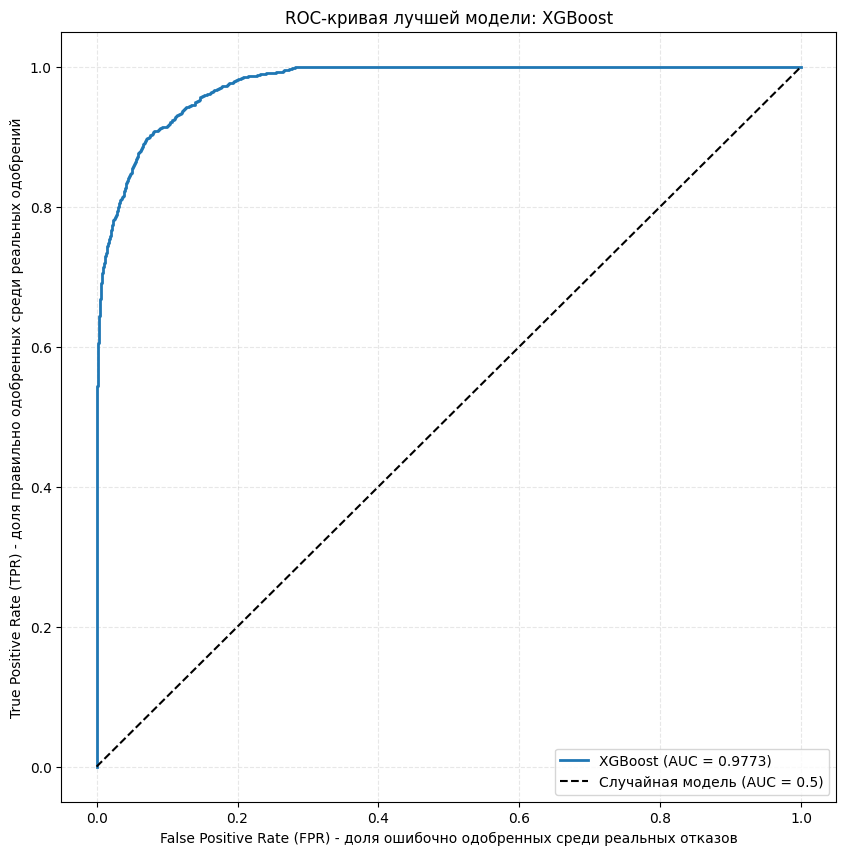


График сохранен: best_model_roc.png


In [ ]:
plt.figure(figsize=(10, 10))
fpr, tpr, _ = roc_curve(y_test, best_model.predict_proba(X_test)[:, 1])
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {best_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель (AUC = 0.5)')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlabel('False Positive Rate (FPR) - доля ошибочно одобренных среди реальных отказов')
plt.ylabel('True Positive Rate (TPR) - доля правильно одобренных среди реальных одобрений')
plt.title(f'ROC-кривая лучшей модели: {best_model_name}')
plt.legend()
plt.show()
plt.grid(alpha=0.3)
plt.savefig('best_model_roc.png', dpi=150)
plt.close()
print('\nГрафик сохранен: best_model_roc.png')

# Сохранение пайплайна и признаков

Пайплайн

In [ ]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', selector),
    ('classifier', best_model)
])

full_pipeline.fit(X, y)

joblib.dump(full_pipeline, 'model.pkl')
print('model.pkl сохранен (полный пайплайн)')

model.pkl сохранен (полный пайплайн)


Признаки

In [ ]:
features_info = {
    'selected_features': selected_features,
    'all_original_features': X.columns.tolist(),
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'best_model': best_model_name,
    'roc_auc_score': float(best_auc),
    'n_selected_features': len(selected_features),
    'model_parameters': str(best_model.get_params())
}

with open('features.json', 'w', encoding='utf-8') as f:
    json.dump(features_info, f, indent=2, ensure_ascii=False)
print('features.json сохранен')

features.json сохранен
